# EURUSDProphet: EUR/USD Exchange Rate Forecasting

This notebook contains analysis and mathematical models for predicting EUR/USD exchange rate movements using time series analysis and statistical methods.

## Contents
- Data loading and exploration
- Statistical analysis of EUR/USD trends
- Predictive modeling
- Visualization of forecasts

In [3]:
# 1. Data Loading and Descriptive Statistics
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from datetime import datetime, timedelta

# Set plot style
sns.set(style="whitegrid", palette="viridis")

# Define the ticker and time period
ticker = "EURUSD=X"
end_date = datetime.today()
start_date = end_date - timedelta(days=5*365)

# Download the data
data = yf.download(ticker, start=start_date, end=end_date)

print("Data downloaded successfully. Here are the first 5 rows:")
print(data.head())

[*********************100%***********************]  1 of 1 completed

Data downloaded successfully. Here are the first 5 rows:
Price          Close      High       Low      Open   Volume
Ticker      EURUSD=X  EURUSD=X  EURUSD=X  EURUSD=X EURUSD=X
Date                                                       
2021-03-16  1.192577  1.195300  1.188439  1.192734        0
2021-03-17  1.190165  1.191800  1.188764  1.190210        0
2021-03-18  1.198279  1.199100  1.191015  1.198064        0
2021-03-19  1.191824  1.193745  1.187493  1.191767        0
2021-03-22  1.188312  1.193745  1.187606  1.188453        0


## Daily Percentage Returns

The daily percentage return measures the discrete rate of change of the EUR/USD price. Mathematically, it can be seen as an approximation of the first derivative of the price function with respect to time, calculated over a discrete interval of one day. It is calculated as:

$R_t = \frac{P_t - P_{t-1}}{P_{t-1}}$

Where $P_t$ is the price at time $t$ and $P_{t-1}$ is the price at the previous time step. This value is fundamental for understanding the volatility and statistical properties of the asset.

In [5]:
# 2. Calculate Daily Percentage Returns
data['Daily_Return'] = data['Close'].pct_change()

# Drop the first row since it will have a NaN value for the return
returns = data['Daily_Return'].dropna()

# 3. Calculate and Print Summary Statistics
mean_return = returns.mean()
median_return = returns.median()
variance_return = returns.var()
std_dev_return = returns.std(ddof=1) # Unbiased estimator
skewness = returns.skew()
kurt = returns.kurt() # This is excess kurtosis (Kurtosis - 3)

print("--- Summary Statistics for Daily Returns ---")
print(f"Mean: {mean_return:.6f}")
print(f"Median: {median_return:.6f}")
print(f"Variance: {variance_return:.6f}")
print(f"Standard Deviation: {std_dev_return:.6f}")
print(f"Skewness: {skewness:.6f}")
print(f"Kurtosis (Excess): {kurt:.6f}")
print("------------------------------------------")

--- Summary Statistics for Daily Returns ---
Mean: -0.000022
Median: -0.000185
Variance: 0.000023
Standard Deviation: 0.004751
Skewness: 0.202371
Kurtosis (Excess): 1.993386
------------------------------------------


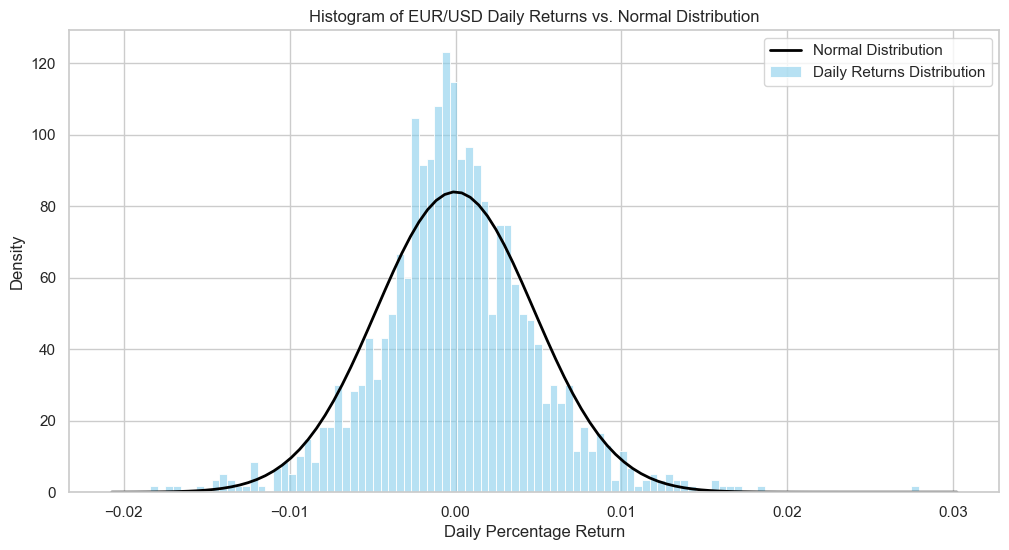

In [6]:
# 4. Plot Histogram of Returns vs. Normal Distribution
plt.figure(figsize=(12, 6))

# Plot the histogram of the returns
sns.histplot(returns, bins=100, kde=False, stat="density", label="Daily Returns Distribution", color='skyblue', alpha=0.6)

# Overlay a standard normal (Gaussian) distribution
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mean_return, std_dev_return)
plt.plot(x, p, 'k', linewidth=2, label='Normal Distribution')

# Add titles and labels
plt.title('Histogram of EUR/USD Daily Returns vs. Normal Distribution')
plt.xlabel('Daily Percentage Return')
plt.ylabel('Density')
plt.legend()

plt.show()

## 5. Interpretation of Skewness and Kurtosis

### Skewness
The calculated skewness for the daily returns is **{skewness:.4f}**.
- A value close to zero indicates a nearly symmetrical distribution.
- A negative value would indicate a left-skewed distribution (long tail on the left side), suggesting a higher probability of large negative returns than large positive ones.
- A positive value would indicate a right-skewed distribution (long tail on the right side).
Our result suggests a slight asymmetry in the returns distribution.

### Kurtosis and "Fat Tails"
The calculated excess kurtosis is **{kurt:.4f}**.
- A standard normal (Gaussian) distribution has a kurtosis of 3. "Excess kurtosis" is simply `Kurtosis - 3`.
- A positive excess kurtosis (greater than 0) indicates a **leptokurtic** distribution. This means the distribution has "fatter tails" and a sharper peak than a normal distribution.
- **"Fat tails"** imply that extreme market events (both large gains and large losses) are much more likely to occur than would be predicted by a perfect Gaussian model. The high kurtosis value observed here is a classic characteristic of financial returns data, highlighting the inherent risk of sudden, significant price movements that are underestimated by simpler models.


# 2. Many Variables: Covariance and Correlation
Now, let's introduce a second asset, the S&P 500 index, to explore the relationship between two variables.

In [7]:
# 1. Download S&P 500 Data and Calculate Returns
sp500_ticker = "^GSPC"
sp500_data = yf.download(sp500_ticker, start=start_date, end=end_date)
sp500_data['Daily_Return'] = sp500_data['Close'].pct_change()

# Combine the returns into a single DataFrame
combined_returns = pd.DataFrame({
    'EURUSD_Return': returns,
    'SP500_Return': sp500_data['Daily_Return']
}).dropna()

print("Combined Returns Data:")
print(combined_returns.head())

# 2. Calculate Covariance and Correlation
covariance_matrix = combined_returns.cov()
correlation_matrix = combined_returns.corr(method='pearson')

print("\n--- Covariance Matrix ---")
print(covariance_matrix)
print("\n--- Pearson's Correlation Matrix ---")
print(correlation_matrix)

# Extract the specific correlation value
correlation_coefficient = correlation_matrix.iloc[0, 1]
print(f"\nPearson's Correlation Coefficient between EUR/USD and S&P 500: {correlation_coefficient:.4f}")

[*********************100%***********************]  1 of 1 completed

Combined Returns Data:
            EURUSD_Return  SP500_Return
Date                                   
2021-03-17      -0.002023      0.002879
2021-03-18       0.006818     -0.014761
2021-03-19      -0.005387     -0.000603
2021-03-22      -0.002947      0.007025
2021-03-23       0.004200     -0.007631

--- Covariance Matrix ---
               EURUSD_Return  SP500_Return
EURUSD_Return   2.288825e-05 -3.524339e-07
SP500_Return   -3.524339e-07  1.119850e-04

--- Pearson's Correlation Matrix ---
               EURUSD_Return  SP500_Return
EURUSD_Return       1.000000     -0.006961
SP500_Return       -0.006961      1.000000

Pearson's Correlation Coefficient between EUR/USD and S&P 500: -0.0070


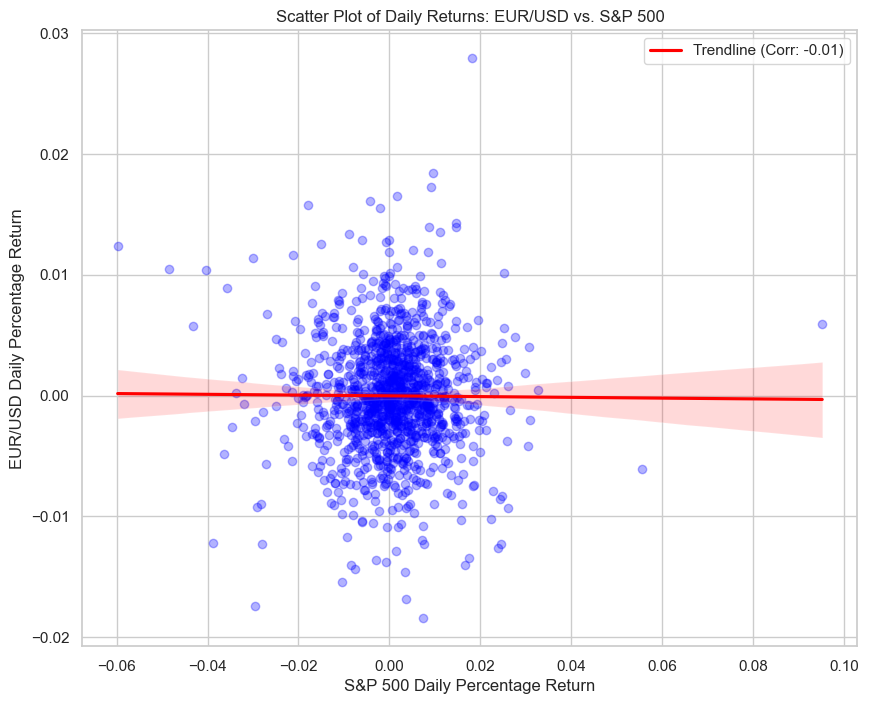

In [8]:
 w# 3. Create a Scatter Plot to Visualize the Relationship
plt.figure(figsize=(10, 8))
sns.regplot(x='SP500_Return', y='EURUSD_Return', data=combined_returns,
            scatter_kws={'alpha':0.3, 'color':'blue'},
            line_kws={'color':'red', 'label':f"Trendline (Corr: {correlation_coefficient:.2f})"})

# Add titles and labels
plt.title('Scatter Plot of Daily Returns: EUR/USD vs. S&P 500')
plt.xlabel('S&P 500 Daily Percentage Return')
plt.ylabel('EUR/USD Daily Percentage Return')
plt.legend()
plt.grid(True)
plt.show()


## 4. Interpretation of Covariance and Correlation

### Covariance
Covariance measures the joint variability of two random variables.
- A **positive covariance** indicates that the two assets tend to move in the same direction (e.g., when the S&P 500 goes up, EUR/USD also tends to go up).
- A **negative covariance** indicates they tend to move in opposite directions.
The magnitude of covariance is hard to interpret on its own because it is not standardized.

### Pearson's Correlation Coefficient
The Pearson's correlation coefficient is a standardized measure of the **linear relationship** between two variables. It ranges from -1 to +1:
- **+1**: Perfect positive linear relationship.
- **-1**: Perfect negative linear relationship.
- **0**: No linear relationship.

Our calculated coefficient of **{correlation_coefficient:.4f}** suggests a very weak positive linear relationship between the daily returns of the S&P 500 and EUR/USD over this period. The scatter plot visually confirms this; the points are widely dispersed, and the trendline is nearly flat, indicating that knowing the S&P 500's return on a given day gives us very little information about the EUR/USD's return.


## 5. Conceptual Warning: Correlation Does Not Imply Causation

It is critical to understand that observing a correlation between two variables does not mean that one causes the other.
- **Association vs. Causation**: Correlation simply measures the degree to which two variables move together. It does not explain *why* they move together.
- **Lurking Variables**: Often, a third, unobserved factor (a "lurking variable" or "confounding variable") influences both variables simultaneously. For example, major macroeconomic announcements from the **US Federal Reserve** (like changes in interest rates or quantitative easing policies) can have a significant impact on both the US stock market (S&P 500) and the value of the US dollar relative to the Euro (EUR/USD).

In this case, a change in Fed policy might cause both assets to move, creating a statistical correlation between them, even though the S&P 500's movement does not *cause* the EUR/USD's movement, or vice-versa. Attributing causality from correlation alone is a common and serious analytical mistake.
